# 🎓 Campus Support Agent — TF-IDF, SVD, PCA, and Model Evaluation

This notebook extends the **Campus Support Agent** project without changing the main idea of the project.

The app can still stay as a **retrieval-based campus assistant**, but this notebook adds an **analytics and evaluation layer** so the project also covers:

- **TF-IDF** for text-to-numerical conversion
- **Confusion Matrix** for classification evaluation
- **SVD (Singular Value Decomposition)**
- **PCA (Principal Component Analysis)**
- **Model Evaluation** to compare different approaches

## Goal of this notebook

We will classify campus questions into simple intent categories such as:

- `hours`
- `location`
- `contact`
- `procedure`
- `other`

This keeps the work aligned with the current project because the Campus Support Agent already handles these types of questions.


In [1]:
# If needed, install packages first
# Uncomment the next line only if your environment does not already have them
# %pip install gensim scikit-learn numpy pandas matplotlib seaborn

import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


## 1. Load the Campus Support knowledge base

This cell tries to load the existing `knowledge_base.json` from common project locations.

Expected paths:
- `data/knowledge_base.json`
- `../data/knowledge_base.json`

If the file is not found, the notebook raises an error so you know where to place the data file.


In [2]:
def find_kb_path():
    candidate_paths = [
        Path('data/knowledge_base.json'),
        Path('../data/knowledge_base.json'),
        Path('./knowledge_base.json'),
    ]
    for path in candidate_paths:
        if path.exists():
            return path
    raise FileNotFoundError(
        'Could not find knowledge_base.json. Place it in data/knowledge_base.json or ../data/knowledge_base.json.'
    )

kb_path = find_kb_path()
print(f'Knowledge base found at: {kb_path.resolve()}')

with open(kb_path, 'r', encoding='utf-8') as f:
    kb = json.load(f)

print(f'Total records loaded: {len(kb)}')
kb[:2] if isinstance(kb, list) else type(kb)


Knowledge base found at: C:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\data\knowledge_base.json
Total records loaded: 80


[{'question': 'What time does the library open?',
  'answer': 'The library opens at 8:00 AM on weekdays.'},
 {'question': 'When does the computer lab close?',
  'answer': 'The computer lab closes at 10:00 PM from Monday to Friday.'}]

## 2. Convert the knowledge base into a DataFrame

This notebook expects each item to contain at least a **question** and an **answer**.


In [3]:
rows = []
for item in kb:
    q = item.get('question', '').strip()
    a = item.get('answer', '').strip()
    if q:
        rows.append({
            'question': q,
            'answer': a,
            'combined_text': f'{q} {a}'.strip()
        })

df = pd.DataFrame(rows)
print('Data shape:', df.shape)
df.head()


Data shape: (80, 3)


,question,answer,combined_text
0,What time does the library open?,The library opens at 8:00 AM on weekdays.,What time does the library open? The library o...
1,When does the computer lab close?,The computer lab closes at 10:00 PM from Monda...,When does the computer lab close? The computer...
2,How can I contact student services?,"You can contact student services by phone, ema...",How can I contact student services? You can co...
3,What is the registration deadline?,The registration deadline is Friday at 4:00 PM.,What is the registration deadline? The registr...
4,Is there a gym on campus?,"Yes, there is a gym on campus for students.","Is there a gym on campus? Yes, there is a gym ..."


## 3. Create intent labels

To satisfy the classification and confusion-matrix part of the requirement, we create simple intent labels from the campus questions.

This keeps the notebook connected to the existing project because the app already answers these kinds of questions.


In [4]:
def infer_intent(text: str) -> str:
    text = text.lower()

    hours_patterns = [
        r'\bopen\b', r'\bclose\b', r'\bhours?\b', r'\btime\b', r'\bwhen\b'
    ]
    location_patterns = [
        r'\bwhere\b', r'\blocated\b', r'\blocation\b', r'\broom\b', r'\bbuilding\b'
    ]
    contact_patterns = [
        r'\bcontact\b', r'\bphone\b', r'\bemail\b', r'\bcall\b', r'\breach\b'
    ]
    procedure_patterns = [
        r'\bhow\b', r'\bapply\b', r'\bprocess\b', r'\bprocedure\b', r'\bsteps\b',
        r'\bregister\b', r'\benroll\b', r'\bbook\b', r'\bget\b'
    ]

    if any(re.search(p, text) for p in hours_patterns):
        return 'hours'
    if any(re.search(p, text) for p in location_patterns):
        return 'location'
    if any(re.search(p, text) for p in contact_patterns):
        return 'contact'
    if any(re.search(p, text) for p in procedure_patterns):
        return 'procedure'
    return 'other'

df['intent'] = df['question'].apply(infer_intent)

print(df['intent'].value_counts())
df[['question', 'intent']].head(10)


intent
other        28
procedure    24
location     15
hours         9
contact       4
Name: count, dtype: int64


,question,intent
0,What time does the library open?,hours
1,When does the computer lab close?,hours
2,How can I contact student services?,contact
3,What is the registration deadline?,other
4,Is there a gym on campus?,other
5,Where is the financial aid office?,location
6,Where can I get academic advising?,location
7,How do I reset my student portal password?,procedure
8,Where can I buy textbooks?,location
9,What time is the cafeteria open?,hours


## 4. Check class balance

This helps us see whether the dataset is reasonably distributed across intent types.


,count
intent,
contact,4
hours,9
location,15
other,28
procedure,24


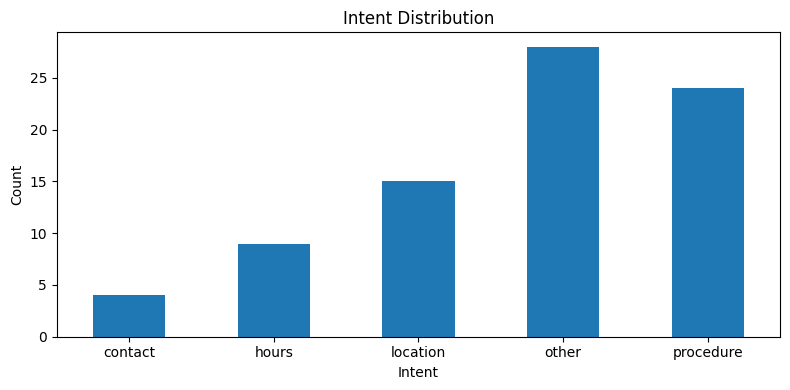

In [5]:
intent_counts = df['intent'].value_counts().sort_index()
display(intent_counts.to_frame('count'))

plt.figure(figsize=(8, 4))
intent_counts.plot(kind='bar')
plt.title('Intent Distribution')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Train-test split

We use **combined question + answer text** as the input feature text.  
The target is the inferred **intent** label.


In [6]:
X = df[['combined_text']]
y = df['intent']

min_class_count = y.value_counts().min()
use_stratify = min_class_count >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y if use_stratify else None
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain label distribution:')
print(y_train.value_counts())


Train shape: (60, 1)
Test shape: (20, 1)

Train label distribution:
intent
other        21
procedure    18
location     11
hours         7
contact       3
Name: count, dtype: int64


## 6. Baseline Model — TF-IDF + Logistic Regression

This is the first required approach.

- **TF-IDF** converts text into numerical features
- **Logistic Regression** performs the classification


In [7]:
from sklearn.pipeline import Pipeline

tfidf_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=2000))
])

tfidf_baseline.fit(X_train['combined_text'], y_train)
pred_baseline = tfidf_baseline.predict(X_test['combined_text'])

baseline_acc = accuracy_score(y_test, pred_baseline)
print('Baseline Accuracy:', round(baseline_acc, 4))
print()
print(classification_report(y_test, pred_baseline))


Baseline Accuracy: 0.45

              precision    recall  f1-score   support

     contact       0.00      0.00      0.00         1
       hours       0.00      0.00      0.00         2
    location       0.00      0.00      0.00         4
       other       0.44      0.57      0.50         7
   procedure       0.45      0.83      0.59         6

    accuracy                           0.45        20
   macro avg       0.18      0.28      0.22        20
weighted avg       0.29      0.45      0.35        20



c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

## 7. Confusion Matrix — Baseline Model

This directly satisfies the **confusion matrix** requirement.


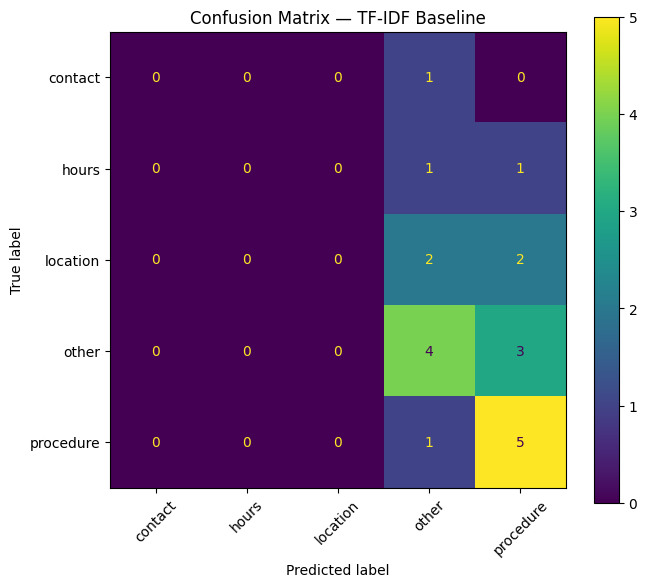

In [8]:
cm_baseline = confusion_matrix(y_test, pred_baseline, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — TF-IDF Baseline')
plt.tight_layout()
plt.show()


## 8. Model 2 — TF-IDF + SVD + Logistic Regression

This model uses **TruncatedSVD**, which is commonly used with sparse TF-IDF text features.

This satisfies the **SVD** requirement.


In [9]:
svd_model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=800)),
    ('svd', TruncatedSVD(n_components=50, random_state=42)),
    ('clf', LogisticRegression(max_iter=2000))
])

svd_model.fit(X_train['combined_text'], y_train)
pred_svd = svd_model.predict(X_test['combined_text'])

svd_acc = accuracy_score(y_test, pred_svd)
print('SVD Model Accuracy:', round(svd_acc, 4))
print()
print(classification_report(y_test, pred_svd))


SVD Model Accuracy: 0.45

              precision    recall  f1-score   support

     contact       0.00      0.00      0.00         1
       hours       0.00      0.00      0.00         2
    location       0.00      0.00      0.00         4
       other       0.44      0.57      0.50         7
   procedure       0.45      0.83      0.59         6

    accuracy                           0.45        20
   macro avg       0.18      0.28      0.22        20
weighted avg       0.29      0.45      0.35        20



c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

## 9. Model 3 — TF-IDF + PCA + Logistic Regression

PCA works on dense numeric input, so we first convert TF-IDF output into a dense array.

Because TF-IDF can create many columns, we limit the vocabulary size with `max_features`.


In [10]:
tfidf_for_pca = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=300)
X_train_tfidf_dense = tfidf_for_pca.fit_transform(X_train['combined_text']).toarray()
X_test_tfidf_dense = tfidf_for_pca.transform(X_test['combined_text']).toarray()

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train_tfidf_dense)
X_test_scaled = scaler.transform(X_test_tfidf_dense)

max_components = min(50, X_train_scaled.shape[0], X_train_scaled.shape[1])
if max_components < 2:
    raise ValueError('Not enough data for PCA. Add more records to the knowledge base.')

pca = PCA(n_components=max_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_clf = LogisticRegression(max_iter=2000)
pca_clf.fit(X_train_pca, y_train)
pred_pca = pca_clf.predict(X_test_pca)

pca_acc = accuracy_score(y_test, pred_pca)
print('PCA Model Accuracy:', round(pca_acc, 4))
print()
print(classification_report(y_test, pred_pca))


PCA Model Accuracy: 0.5

              precision    recall  f1-score   support

     contact       0.00      0.00      0.00         1
       hours       0.00      0.00      0.00         2
    location       0.33      0.25      0.29         4
       other       0.67      0.57      0.62         7
   procedure       0.45      0.83      0.59         6

    accuracy                           0.50        20
   macro avg       0.29      0.33      0.30        20
weighted avg       0.44      0.50      0.45        20



c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kevin\Downloads\Campus_Support_Agent_Updated\PROG8245-CSCN8010-Final-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

## 10. Confusion Matrix — Best Model

Now we compare the models and plot the confusion matrix for the best one.


,Model,Accuracy
0,TF-IDF + PCA + Logistic Regression,0.50
1,TF-IDF + Logistic Regression,0.45
2,TF-IDF + SVD + Logistic Regression,0.45


Best model: TF-IDF + PCA + Logistic Regression


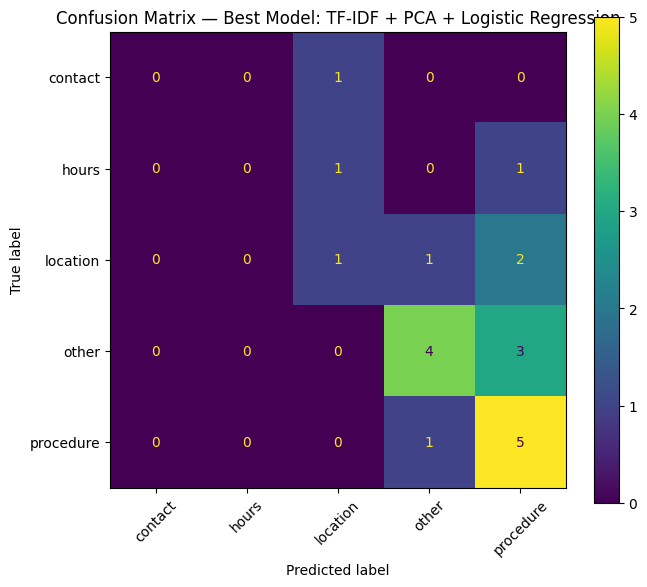

In [11]:
results = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'TF-IDF + SVD + Logistic Regression',
        'TF-IDF + PCA + Logistic Regression'
    ],
    'Accuracy': [
        baseline_acc,
        svd_acc,
        pca_acc
    ]
}).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(results)

best_name = results.loc[0, 'Model']
print('Best model:', best_name)

if best_name == 'TF-IDF + Logistic Regression':
    best_pred = pred_baseline
elif best_name == 'TF-IDF + SVD + Logistic Regression':
    best_pred = pred_svd
else:
    best_pred = pred_pca

cm_best = confusion_matrix(y_test, best_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=sorted(y.unique()))

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f'Confusion Matrix — Best Model: {best_name}')
plt.tight_layout()
plt.show()


## 11. Visual comparison of model accuracy

This section satisfies the **model evaluation** requirement by comparing different approaches.


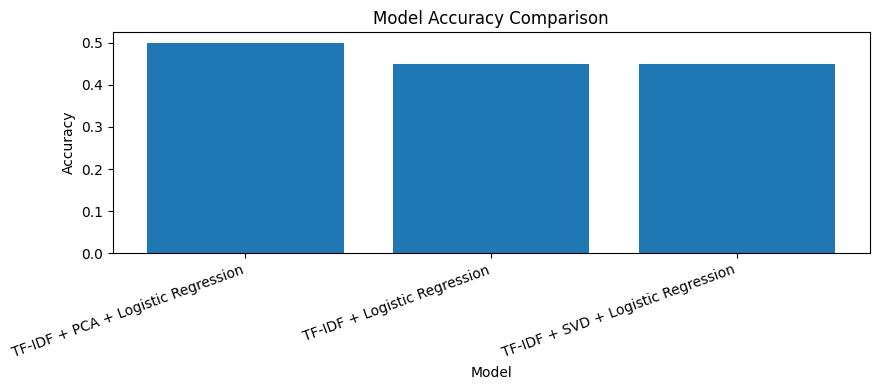

,Model,Accuracy
0,TF-IDF + PCA + Logistic Regression,0.50
1,TF-IDF + Logistic Regression,0.45
2,TF-IDF + SVD + Logistic Regression,0.45


In [12]:
plt.figure(figsize=(9, 4))
plt.bar(results['Model'], results['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

results


## 12. PCA explained variance

This helps explain how much variance is preserved by the PCA transformation.


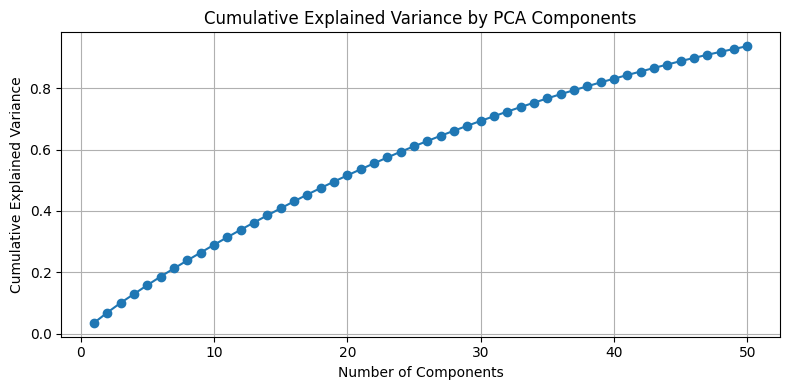

Final cumulative explained variance: 0.937


In [13]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Final cumulative explained variance:', round(explained_variance[-1], 4))


## 13. Short project conclusion

### What this notebook added to the project

This notebook keeps the **Campus Support Agent** idea the same, but adds a machine-learning evaluation layer:

- **TF-IDF** was used to convert campus questions into numerical features
- **Confusion Matrix** was used to evaluate classification performance
- **SVD** was applied through `TruncatedSVD`
- **PCA** was applied on dense TF-IDF vectors
- **Model Evaluation** was used to compare three approaches

### Recommended explanation for presentation

You can say:

> “Our main project remains a campus support agent. To satisfy the machine learning requirements, we added a notebook that classifies campus question intents using TF-IDF, SVD, PCA, and confusion-matrix-based evaluation. This keeps the project aligned with the original idea while also meeting the academic requirements.”
